<a href="https://www.kaggle.com/code/vishroy/logistic-regression-titanic?scriptVersionId=341374188" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Round 1

## 1. Load and inspect dataset

In [42]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
print(df.head())
df_raw = df.copy()

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [43]:
df_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


we have missing values for age and cabin.

For cabin - only class 1 has cabin rest should be filled with NA.
For age - we need to investigate

questions :

1. I think we don't need passengerId, SibSp, Parch, Cabin, Embarked for this prediction

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## 2. Missing values

In [5]:
df['Age'].isna().value_counts()

Age
False    714
True     177
Name: count, dtype: int64

In [6]:
df['Cabin'].isna().value_counts()

Cabin
True     687
False    204
Name: count, dtype: int64

In [7]:
df['Cabin'] = df['Cabin'].fillna('NA')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NA,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NA,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NA,S


In [8]:
df.groupby('Pclass')['Age'].apply(lambda x: x.isnull().sum())

Pclass
1     30
2     11
3    136
Name: Age, dtype: int64

In [9]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [10]:
df.groupby('Sex')['Age'].apply(lambda x: x.isnull().sum())

Sex
female     53
male      124
Name: Age, dtype: int64

In [11]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

1. Pclass 1: 30/216 = ~13.9% missing
2. Pclass 2: 11/184 = ~6.0% missing
3. Pclass 3: 136/491 = ~27.7% missing
4. Male: 124/577 = ~21.5% missing
5. Female: 53/314 = ~16.9% missing

In [12]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: >

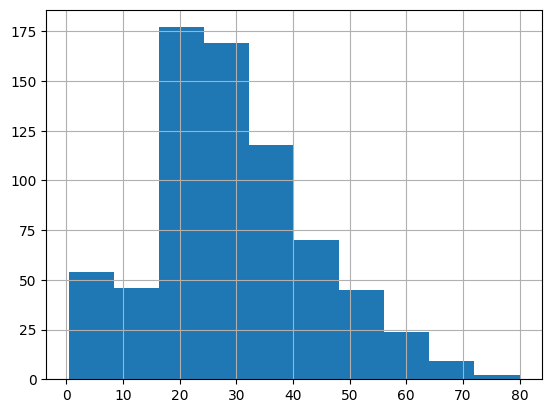

In [13]:
df['Age'].hist()

In [14]:
df.groupby(['Pclass','Sex'])['Age'].mean()

Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64

In [15]:
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('mean'))

In [16]:
df['Age'].isna().sum()

np.int64(0)

## 3. Encoding

In [17]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [18]:
df['Cabin'].nunique()

148

In [19]:
df['Ticket'].nunique()

681

1. Drop: PassengerId, Name, Ticket and Cabin
2. One-Hot Encode(Categorical Columns): Sex, Embarked
3. Keep As-is (already numeric, meaningful): Age, SibSp, Parch, Fare,Pclass

In [20]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform='pandas')

encoded_df = encoder.fit_transform(df[['Sex', 'Embarked']])

print(encoded_df)

     Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Embarked_nan
0           0.0       1.0         0.0         0.0         1.0           0.0
1           1.0       0.0         1.0         0.0         0.0           0.0
2           1.0       0.0         0.0         0.0         1.0           0.0
3           1.0       0.0         0.0         0.0         1.0           0.0
4           0.0       1.0         0.0         0.0         1.0           0.0
..          ...       ...         ...         ...         ...           ...
886         0.0       1.0         0.0         0.0         1.0           0.0
887         1.0       0.0         0.0         0.0         1.0           0.0
888         1.0       0.0         0.0         0.0         1.0           0.0
889         0.0       1.0         1.0         0.0         0.0           0.0
890         0.0       1.0         0.0         1.0         0.0           0.0

[891 rows x 6 columns]


In [22]:
df['Embarked'].isnull().sum()

np.int64(2)

In [23]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [24]:
df['Embarked'].mode()[0]

'S'

In [25]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'].isnull().sum()

np.int64(0)

In [26]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform='pandas')

encoded_df = encoder.fit_transform(df[['Sex', 'Embarked']])

print(encoded_df)

     Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S
0           0.0       1.0         0.0         0.0         1.0
1           1.0       0.0         1.0         0.0         0.0
2           1.0       0.0         0.0         0.0         1.0
3           1.0       0.0         0.0         0.0         1.0
4           0.0       1.0         0.0         0.0         1.0
..          ...       ...         ...         ...         ...
886         0.0       1.0         0.0         0.0         1.0
887         1.0       0.0         0.0         0.0         1.0
888         1.0       0.0         0.0         0.0         1.0
889         0.0       1.0         1.0         0.0         0.0
890         0.0       1.0         0.0         1.0         0.0

[891 rows x 5 columns]


In [27]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [28]:
df = df.drop(columns = ['Sex', 'Embarked'])
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [29]:
final_df = pd.concat([df, encoded_df], axis=1)

final_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0


In [30]:
final_df.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_female    float64
Sex_male      float64
Embarked_C    float64
Embarked_Q    float64
Embarked_S    float64
dtype: object

In [31]:
final_df.isnull().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_female    0
Sex_male      0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

## 4. Train-Test Split and Model Training

In [32]:
X = final_df.drop(columns=['Survived'])
y = final_df['Survived']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (712, 10)
Testing features shape: (179, 10)


In [34]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Scaling karna hai

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(y_pred)
print(model.predict_proba(X_test_scaled))

[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 0 1 0 0 1 0]
[[0.93768095 0.06231905]
 [0.95844271 0.04155729]
 [0.85137565 0.14862435]
 [0.97003729 0.02996271]
 [0.2902492  0.7097508 ]
 [0.58419368 0.41580632]
 [0.24200121 0.75799879]
 [0.65705446 0.34294554]
 [0.65984961 0.34015039]
 [0.83989833 0.16010167]
 [0.84458195 0.15541805]
 [0.91457494 0.08542506]
 [0.42259092 0.57740908]
 [0.77287925 0.22712075]
 [0.51253032 0.48746968]
 [0.83568224 0.16431776]
 [0.58109266 0.41890734]
 [0.90914861 0.09085139]
 [0.86840564 0.13159436]
 [0.22623674 0.77376326]
 [0.90914861 0.09085139]
 [0.21378129 0.78621871]
 [0.92106118 0.07893882]
 [0.59182063 0.40817937]
 [0.91782887 0.08217113]
 [0.0338506

## 5. Evaluation

In [36]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8212290502793296

In [37]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[99, 11],
       [21, 48]])

* TN (True Negative) = 99
* FP (False Positive) = 11
* FN (False Negative) = 21
* TP (True Positive) = 48

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

print(classification_report(y_test, y_pred))

Precision: 0.814
Recall: 0.696
F1-score: 0.750
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [39]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [40]:
final_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0


## Titanic Survival Prediction — Pipeline Summary

### Key Lesson Learned
Always keep a **raw copy** of the original dataset (`df_raw = df.copy()`) before dropping columns. Feature engineering should happen **before** encoding, since it often needs raw text/data (like `Name`) that gets removed during cleanup.

### Correct Pipeline Order
1. **Load raw data** — keep an untouched copy for reference
2. **Missing value handling**
   - `Age` → filled using group-wise mean (`groupby(['Pclass','Sex'])`)
   - `Embarked` → filled using mode (most frequent value)
   - `Cabin` → filled with `'NA'` (later dropped due to high cardinality)
3. **Feature Engineering** (new — do this before dropping/encoding)
   - `FamilySize = SibSp + Parch + 1`
   - `IsAlone = 1 if FamilySize == 1 else 0`
   - `Title` → extracted from `Name` using regex (Mr/Mrs/Miss/Master/etc.)
4. **Drop unnecessary columns**
   - `PassengerId`, `Name`, `Ticket`, `Cabin` (and `SibSp`/`Parch` optionally, since `FamilySize` replaces their info)
5. **Encoding**
   - `Sex`, `Embarked`, `Title` → One-Hot Encoding (nominal, no order)
   - `Pclass` → kept as-is (ordinal, natural order already meaningful)
6. **Train-Test Split**
   - `test_size=0.2`, `stratify=y` (dataset is imbalanced: ~62% not survived, ~38% survived)
7. **Feature Scaling**
   - `StandardScaler` — `fit_transform` on `X_train`, only `transform` on `X_test` (avoid data leakage)
8. **Model Training**
   - `LogisticRegression().fit(X_train_scaled, y_train)`
9. **Evaluation**
   - Accuracy, Confusion Matrix, Precision/Recall/F1
   - Baseline accuracy = ~61.6% ("always predict not survived")
   - First model result: Accuracy = 82.1%, Recall(Survived) = 0.70 — model slightly biased toward predicting "not survived" due to class imbalance

### Goal for This Round
Re-run the full pipeline with `FamilySize`, `IsAlone`, and `Title` added, and compare new accuracy/recall against the baseline (82.1% / 0.70) to see if feature engineering improved the model.

# Round 2

## 1. Load and inspect data

In [58]:
df_two = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df_two.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
df_two.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [60]:
df_two.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Missing value handling

In [61]:
df_two['Cabin'].isna().sum()

np.int64(687)

In [62]:
df_two['Cabin'].isna().value_counts()

Cabin
True     687
False    204
Name: count, dtype: int64

In [63]:
df_two.groupby('Pclass')['Cabin'].apply(lambda x: x.isnull().sum())

Pclass
1     40
2    168
3    479
Name: Cabin, dtype: int64

In [65]:
df_two['Cabin'] = df_two['Cabin'].fillna('NA')

In [66]:
df_two['Age'].isna().sum()

np.int64(177)

In [67]:
df_two['Age'] = df_two['Age'].fillna(
    df_two.groupby(['Pclass','Sex'])['Age'].transform('mean')
)

In [68]:
print(df_two['Age'].isna().sum())
print(df_two['Cabin'].isna().sum())

0
0


In [69]:
df_two.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [70]:
df_two['Embarked'].isna().sum()

np.int64(2)

In [71]:
df_two['Embarked'] = df_two['Embarked'].fillna(df_two['Embarked'].mode()[0])
df_two['Embarked'].isnull().sum()

np.int64(0)

In [73]:
df_two.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

## 3. Feature Engineering

Feature Engineering (new — do this before dropping/encoding)

* FamilySize = SibSp + Parch + 1
* IsAlone = 1 if FamilySize == 1 else 0
* Title → extracted from Name using regex (Mr/Mrs/Miss/Master/etc.)

In [74]:
df_two['FamilySize'] = df_two['SibSp'] + df_two['Parch'] + 1

df_two.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NA,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NA,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NA,S,1


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [75]:
df_two['isAlone'] = np.where(df_two['FamilySize'] == 1, True, False).astype(int)
df_two[['FamilySize', 'isAlone']].head(10)

,FamilySize,isAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [77]:
df_two['Title'] = df_two['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(df_two['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [78]:
mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
rare_titles = ['Dr', 'Rev', 'Col', 'Don', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer', 'Major']

df_two['Title'] = df_two['Title'].replace(mapping)
df_two['Title'] = np.where(df_two['Title'].isin(rare_titles), 'Rare', df_two['Title'])

In [79]:
print(df_two['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


## 4. Drop unnecessary columns

1. Columns to drop : PassengerId, Name, Cabin, Ticket, SibSp, Parch

In [81]:
df_two.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked',
 'FamilySize',
 'isAlone',
 'Title']

In [82]:
df_two[['Pclass', 'Fare']].corr()

,Pclass,Fare
Pclass,1.0000,-0.5495
Fare,-0.5495,1.0000


In [83]:
df_two = df_two.drop(columns=['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'])

In [84]:
df_two.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,isAlone,Title
0,0,3,male,22.0,7.2500,S,2,0,Mr
1,1,1,female,38.0,71.2833,C,2,0,Mrs
2,1,3,female,26.0,7.9250,S,1,1,Miss
3,1,1,female,35.0,53.1000,S,2,0,Mrs
4,0,3,male,35.0,8.0500,S,1,1,Mr


## 5. Encoding - new

* Sex, Embarked, Title → One-Hot Encoding (nominal, no order)
* Pclass → kept as-is (ordinal, natural order already meaningful)
* Age, isAlone, Fare, FamilySize -> Keep as-is

In [85]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform='pandas')

encoded_df_two = encoder.fit_transform(df_two[['Sex', 'Embarked','Title']])

print(encoded_df_two)

     Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Title_Master  \
0           0.0       1.0         0.0         0.0         1.0           0.0   
1           1.0       0.0         1.0         0.0         0.0           0.0   
2           1.0       0.0         0.0         0.0         1.0           0.0   
3           1.0       0.0         0.0         0.0         1.0           0.0   
4           0.0       1.0         0.0         0.0         1.0           0.0   
..          ...       ...         ...         ...         ...           ...   
886         0.0       1.0         0.0         0.0         1.0           0.0   
887         1.0       0.0         0.0         0.0         1.0           0.0   
888         1.0       0.0         0.0         0.0         1.0           0.0   
889         0.0       1.0         1.0         0.0         0.0           0.0   
890         0.0       1.0         0.0         1.0         0.0           0.0   

     Title_Miss  Title_Mr  Title_Mrs  Title_Rare  


In [86]:
df_two.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,isAlone,Title
0,0,3,male,22.0,7.2500,S,2,0,Mr
1,1,1,female,38.0,71.2833,C,2,0,Mrs
2,1,3,female,26.0,7.9250,S,1,1,Miss
3,1,1,female,35.0,53.1000,S,2,0,Mrs
4,0,3,male,35.0,8.0500,S,1,1,Mr


In [87]:
df_two = df_two.drop(columns = ['Sex', 'Embarked', 'Title'])
df_two.head()

,Survived,Pclass,Age,Fare,FamilySize,isAlone
0,0,3,22.0,7.2500,2,0
1,1,1,38.0,71.2833,2,0
2,1,3,26.0,7.9250,1,1
3,1,1,35.0,53.1000,2,0
4,0,3,35.0,8.0500,1,1


In [88]:
final_df_two = pd.concat([df_two, encoded_df_two], axis=1)

final_df_two.head()

,Survived,Pclass,Age,Fare,FamilySize,isAlone,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,7.2500,2,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1,1,38.0,71.2833,2,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,3,26.0,7.9250,1,1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1,1,35.0,53.1000,2,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0,3,35.0,8.0500,1,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [89]:
final_df_two.dtypes

Survived          int64
Pclass            int64
Age             float64
Fare            float64
FamilySize        int64
isAlone           int64
Sex_female      float64
Sex_male        float64
Embarked_C      float64
Embarked_Q      float64
Embarked_S      float64
Title_Master    float64
Title_Miss      float64
Title_Mr        float64
Title_Mrs       float64
Title_Rare      float64
dtype: object

## 6. Train-test split

In [90]:
from sklearn.model_selection import train_test_split

X = final_df_two.drop(columns = ['Survived'])
y = final_df_two['Survived']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    shuffle=True,
    stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (712, 15)
Testing features shape: (179, 15)


## 7. Feature Scaling

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Model Training

In [92]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(y_pred)
print(model.predict_proba(X_test_scaled))


[0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1 1 1
 0 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 0 1 0 0 1 0]
[[0.95075509 0.04924491]
 [0.9601962  0.0398038 ]
 [0.88065072 0.11934928]
 [0.97173033 0.02826967]
 [0.29122235 0.70877765]
 [0.35264417 0.64735583]
 [0.25032744 0.74967256]
 [0.59727935 0.40272065]
 [0.72209684 0.27790316]
 [0.84928827 0.15071173]
 [0.86931087 0.13068913]
 [0.93829379 0.06170621]
 [0.43335    0.56665   ]
 [0.84565306 0.15434694]
 [0.77030781 0.22969219]
 [0.86370685 0.13629315]
 [0.73197608 0.26802392]
 [0.923031   0.076969  ]
 [0.89855835 0.10144165]
 [0.23845295 0.76154705]
 [0.923031   0.076969  ]
 [0.28977687 0.71022313]
 [0.93064013 0.06935987]
 [0.44928514 0.55071486]
 [0.92857038 0.07142962]
 [0.0206589

## 9. Evaluation

In [93]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8491620111731844

In [94]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[99, 11],
       [16, 53]])

TN (True Negative) = 99
FP (False Positive) = 11
FN (False Negative) = 16
TP (True Positive) = 53

In [95]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

print(classification_report(y_test, y_pred))

Precision: 0.828
Recall: 0.768
F1-score: 0.797
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       110
           1       0.83      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



In [96]:
model.coef_

array([[-0.91863241, -0.42719556,  0.14431783, -0.7059909 , -0.13854441,
         0.5773833 , -0.5773833 ,  0.04684168,  0.0975221 , -0.10018066,
         0.47400233, -0.07836153, -0.27208441,  0.20215083, -0.02001607]])

In [97]:
pd.Series(model.coef_[0], index=X_train.columns)

Pclass         -0.918632
Age            -0.427196
Fare            0.144318
FamilySize     -0.705991
isAlone        -0.138544
Sex_female      0.577383
Sex_male       -0.577383
Embarked_C      0.046842
Embarked_Q      0.097522
Embarked_S     -0.100181
Title_Master    0.474002
Title_Miss     -0.078362
Title_Mr       -0.272084
Title_Mrs       0.202151
Title_Rare     -0.020016
dtype: float64

## Titanic Survival Prediction — Round 2 Results

### New Features Added
- `FamilySize` = SibSp + Parch + 1
- `isAlone` = True if FamilySize == 1, else False
- `Title` = extracted from `Name` using regex, cleaned into 5 categories (Mr, Miss, Mrs, Master, Rare)
- Dropped `SibSp`, `Parch` (redundant after creating `FamilySize`)
- Kept `Pclass` and `Fare` despite moderate correlation (-0.55) — both carry some unique signal
- Skipped VIF check this round (multicollinearity check deferred — not critical for pure accuracy goal)

### Results Comparison

| Metric | Round 1 (baseline) | Round 2 (feature engineered) | Change |
|---|---|---|---|
| Accuracy | 82.1% | 84.9% | ↑ +2.8% |
| Precision | 0.814 | 0.828 | ↑ +0.014 |
| Recall | 0.696 | 0.768 | ↑ +0.072 |
| F1-score | 0.750 | 0.797 | ↑ +0.047 |
| False Negatives | 21 | 16 | ↓ -5 |

**Biggest win: Recall improved the most** — model now misses fewer actual survivors (FN dropped from 21 to 16), meaning it's less "pessimistic" than before.

### Coefficient Insights (from `model.coef_`)
- `Sex_female` (+0.58) vs `Sex_male` (-0.58) — confirms "women first" pattern strongly influenced survival
- `Title_Master` (+0.47) — being a young boy ("Master") positively impacted survival, likely tied to "children first" policy
- `Pclass` (-0.92, largest magnitude) — higher Pclass number (worse class) strongly reduces survival probability
- `FamilySize` (-0.71) — larger family size is associated with lower survival probability in this model

### Key Takeaway
Feature engineering (extracting `Title`, creating `FamilySize`/`isAlone`) added meaningful signal beyond raw features — the model improved without changing the algorithm itself, purely from better inputs. This reinforces that **good features often matter more than a fancier model.**

### Next Steps (Future Ideas)
- Check VIF for multicollinearity between `Pclass`/`Fare` and one-hot pairs
- Try dropping `Fare` or `Pclass` individually to see standalone effect
- Experiment with adjusting decision threshold (currently 0.5) to further improve Recall
- Try OvR (One-vs-Rest) on a multi-class dataset (e.g. Iris) for next practice session